# Python stuff not done in MPR

## List comprehensions

This is a common pattern - accumulating into a list:

In [1]:
inputs = [2, 1, 3, 2, 4, 5, 6]
result = []  # Start with an empty list
for i in inputs:  # Iterate over an input list
    if i < 4:  # if some condition holds
        result.append(i**2)  # Append the result of a calculation
result

[4, 1, 9, 4]

It's common enough that Python includes dedicated syntax for this:

In [2]:
result = [i**2 for i in inputs if i < 4]
result

[4, 1, 9, 4]

## Dictionaries

You should be familiar with lists, which are ordered container types.

In [3]:
lst = [1, 2, 3]

We can retrieve elements from the list by _indexing_ it

In [4]:
lst[1]

2

A dictionary gives us a container like a list, but the indexes can be much more general, not just numbers but strings or sympy variables (and a whole host of other types)

In [5]:
dic = {'a': 100, 2: 45, 100: 45}
dic['a']

100

When we solve an equation in sympy, the result is a dictionary

In [6]:
import sympy
sympy.init_printing()

In [7]:
x, y = sympy.symbols('x, y')

In [8]:
solution = sympy.solve([x - y, 2 + 2*x + y], [x, y])

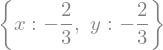

In [9]:
solution

In [10]:
type(solution)

dict

This means we can find the value of one of the answers by indexing.

In [11]:
solution[x]

## Tuples

You are familiar with lists:

In [14]:
l = [1, 2, 3, 4]

In [15]:
type(l)

list

Tuples are like lists, but they are created with commas:

In [16]:
t = 1, 2, 3, 4

In [17]:
type(t)

tuple

In some cases it is useful to use parentheses to group tuples (but note that they are not required syntax:

In [18]:
t2 = (1, 2, 3, 4)

In [19]:
type(t2)

tuple

It is important to understand that the comma, not the parentheses make tuples:

In [20]:
only_one = (((((((1)))))))

In [21]:
type(only_one)

int

In [22]:
only_one = 1,

In [23]:
type(only_one)

tuple

In [24]:
len(only_one)

The only exception to this rule is that an empty tuple is built with `()`:



In [25]:
empty = ()

In [26]:
type(empty)

tuple

In [27]:
len(empty)

The differences between tuples and lists are that tuples are immutable (they cannot be changed in place)

In [28]:
l.append(1)

If we were to run 

```
t.append(1)
```

We would see
```
---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
<ipython-input-41-c860940312ad> in <module>()
----> 1 t.append(1)

AttributeError: 'tuple' object has no attribute 'append'
```

### Tuple expansion

A very useful and general feature of the assignment operator in Python is that tuples will be expanded and assigned in matched patterns:

In [29]:
a, b = 1, 2

This is quite sophisticated and can handle nested structures and expanded to lists:

In [30]:
[(a, b,), c, d] = [(1, 2), 3, 4]

## The for loop in Python

[This talk](https://nedbatchelder.com/text/iter.html) is excellent for understanding the way that Python "wants" to use the for loop

### zip

Let's say we're trying to calculate the credit-weighted average of a student's marks using loops:

In [31]:
credits = [8, 16, 8, 8, 16]
marks = [75, 60, 60, 75, 45]

One way is to use indexing:

In [32]:
weightedsum = 0
creditsum = 0
for i in range(len(credits)):
    weightedsum += credits[i]*marks[i]
    creditsum += credits[i]

avg = weightedsum/creditsum
print(avg)

60.0


But Python supplies a method which allows us to iterate directly over the pairs:

In [33]:
weightedsum = 0
creditsum = 0
for credit, mark in zip(credits, marks):
    weightedsum += credit*mark
    creditsum += credit

avg = weightedsum/creditsum
print(avg)

60.0


This `zip` function returns an iterator which groups its inputs into tuples, suitable for expansion in the for loop. We can see the effect if we convert to a list:

In [34]:
list(zip(credits, marks))

These pairs are then assigned out to the arguments in the for loop above

## lambda

Some functions expect functions as arguments. For instance, `scipy.optimize.fsolve` solves equations numerically:

In [35]:
def f(x):
    return x**2 - 3

In [36]:
import scipy

In [37]:
import scipy.optimize

In [38]:
scipy.optimize.fsolve(f, 2)

array([1.73205081])

For very simple functions, `lambda` allows us to construct functions in a more compact way and not give them a name:

In [39]:
scipy.optimize.fsolve(lambda x: x**2 - 3, 2)

array([1.73205081])

The function constructed by lambda works the same as the one constructed by def in most ways. My recommendation is to use lambda with caution. It is never *necessary* to use `lambda`. I include this section mostly so that you can understand what this does if you encounter it in documentation.